# K-Means Clustering — Heart Disease Risk Dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 1. Load the data

In [4]:
df = pd.read_csv('heart_disease_risk_dataset_earlymed.csv')
print(df.shape)
df.head()

(70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null  float64
 1

Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64

## 2. Preprocess

- Drop `Heart_Risk` — it's the target label, not a feature for unsupervised clustering.
- Scale all features with `StandardScaler`. This matters a lot here: `Age` ranges roughly 20–90 while every other column is 0/1, so without scaling, K-Means (which uses Euclidean distance) would let `Age` dominate the clustering.


In [6]:
X = df.drop(columns=['Heart_Risk'])
y = df['Heart_Risk'] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(70000, 18)

## 3. Find the optimal number of clusters

We use two diagnostics together:
- **Elbow method**: plot inertia (within-cluster sum of squares) vs. k, look for the "elbow".


In [7]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

sample_idx = np.random.RandomState(42).choice(X_scaled.shape[0], size=5000, replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

k=2: inertia=935307.2, silhouette=0.2341
k=3: inertia=901195.3, silhouette=0.1489
k=4: inertia=878978.1, silhouette=0.0656
k=5: inertia=851158.7, silhouette=0.0732
k=6: inertia=839198.1, silhouette=0.0613
k=7: inertia=822712.6, silhouette=0.0665
k=8: inertia=812996.6, silhouette=0.0559
k=9: inertia=801709.9, silhouette=0.0549
k=10: inertia=792566.8, silhouette=0.0603


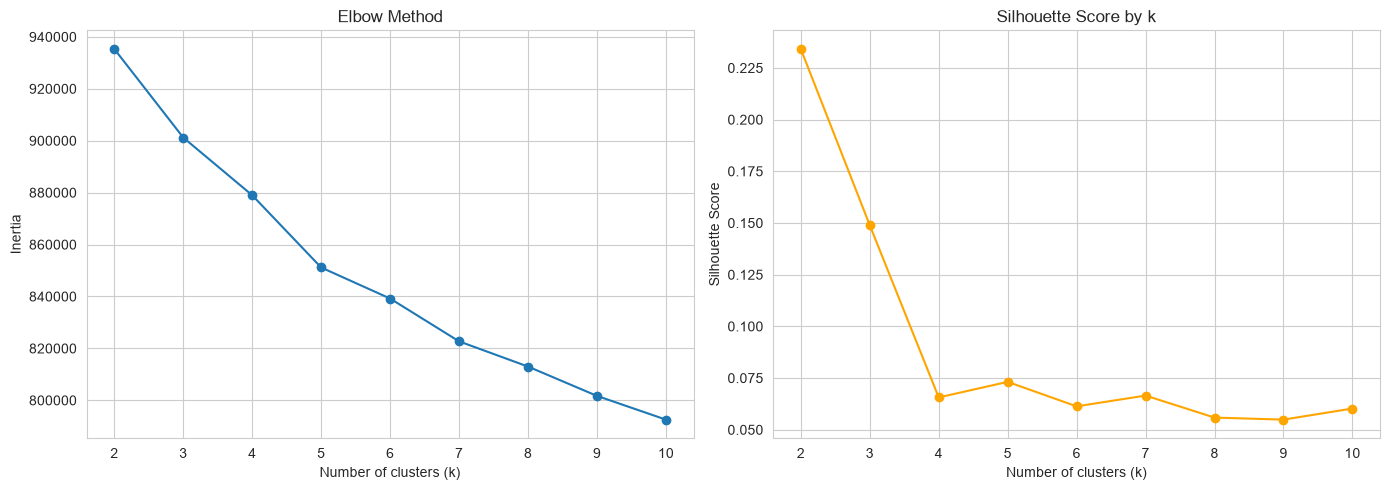

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

## 4. Fit K-Means with the chosen k

Pick `k` based on the elbow/silhouette plots above (update `k_final` if a different value looks better on your run — random risk-factor data like this often clusters best around k=2–4).


In [9]:
k_final = 3 

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'].value_counts().sort_index()

Cluster
0    34774
1    20981
2    14245
Name: count, dtype: int64

## 5. Visualize clusters with PCA

K-Means was fit in the original (scaled) feature space, but we can't visualize 18 dimensions directly. PCA reduces it to 2D just for plotting.


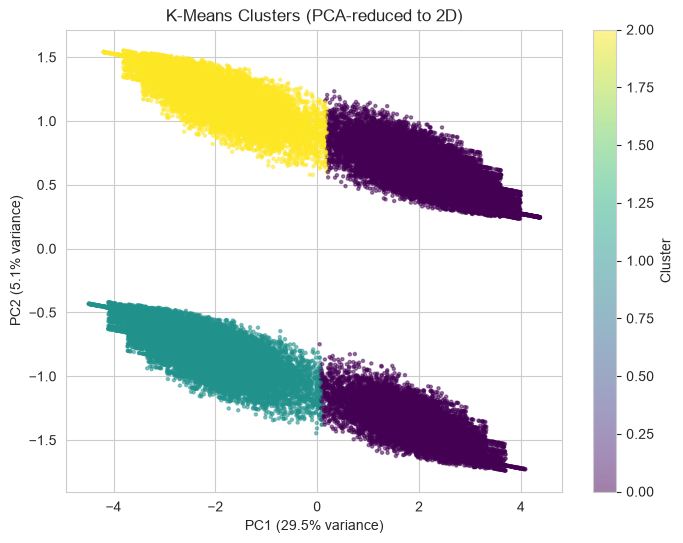

Total variance explained by 2 components: 34.6%


In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=5, alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (PCA-reduced to 2D)')
plt.colorbar(scatter, label='Cluster')
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 6. Profile the clusters

Look at the average value of each feature per cluster to understand what distinguishes them, and cross-check against the (unused) `Heart_Risk` label to see if clusters align with actual risk.


In [11]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
Cluster,,,,,,,,,,,,,,,,,,,
0,0.802007,0.802812,0.800397,0.799793,0.804682,0.801231,0.805084,0.805918,0.701932,0.704118,0.700495,0.704377,0.701242,0.707885,0.698424,0.703198,0.695347,64.393024,0.994335
1,0.199609,0.201230,0.202517,0.201373,0.199609,0.200372,0.203422,0.200562,0.294791,0.295934,0.301559,0.303989,0.300415,0.303751,0.298985,0.297078,0.000000,44.652686,0.008246
2,0.201404,0.203721,0.197824,0.201755,0.205616,0.200702,0.199438,0.206318,0.296665,0.298420,0.306002,0.304388,0.298561,0.298982,0.300035,0.302633,1.000000,44.666760,0.017550


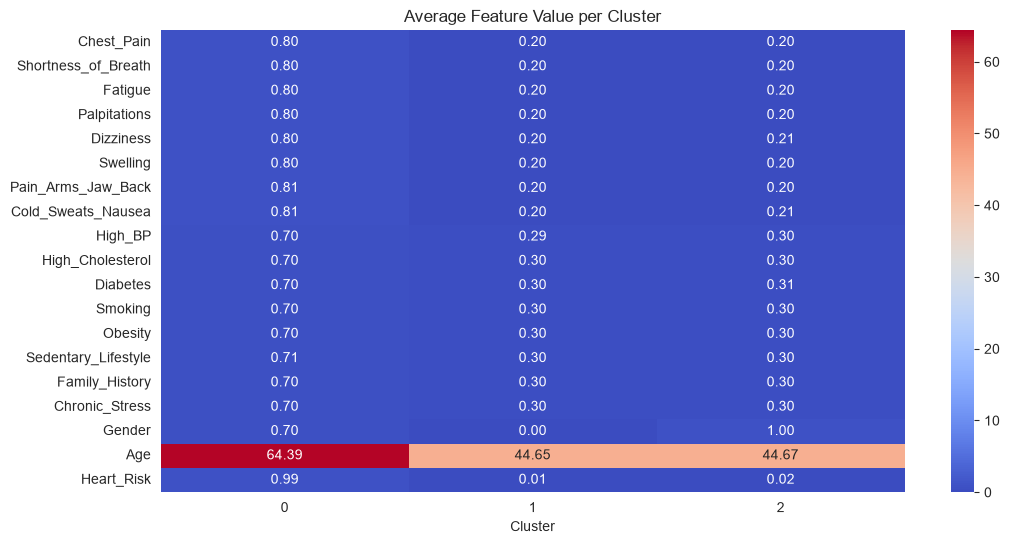

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.drop(columns=['Cluster'], errors='ignore').T,
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Average Feature Value per Cluster')
plt.show()

In [13]:
pd.crosstab(df['Cluster'], df['Heart_Risk'], normalize='index').style.format('{:.1%}')

Heart_Risk,0.000000,1.000000
Cluster,,
0,0.6%,99.4%
1,99.2%,0.8%
2,98.2%,1.8%
